In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('mall_customers.csv')
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000      

In [9]:
# Cell 4 - Check Missing Values and Duplicates
print("Missing Values:", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Missing Values: CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
Duplicates: 0


In [13]:
print(df.columns)

Index(['customer_id', 'Gender', 'age', 'annual_income', 'spending_score'], dtype='str')


In [20]:
df.head()

,customer_id,Gender,age,annual_income,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


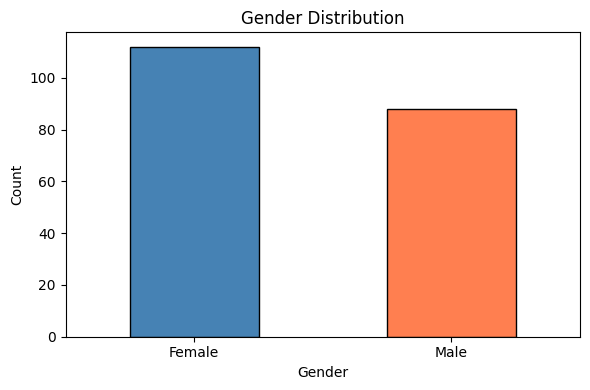

In [21]:
# Cell 6 - Gender Distribution
plt.figure(figsize=(6, 4))
df['Gender'].value_counts().plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

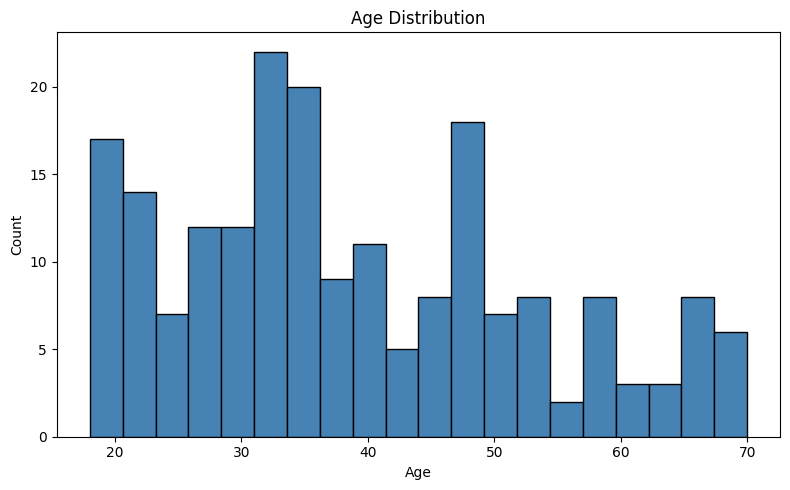

In [23]:
# Cell 7 - Age Distribution
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=20, color='steelblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

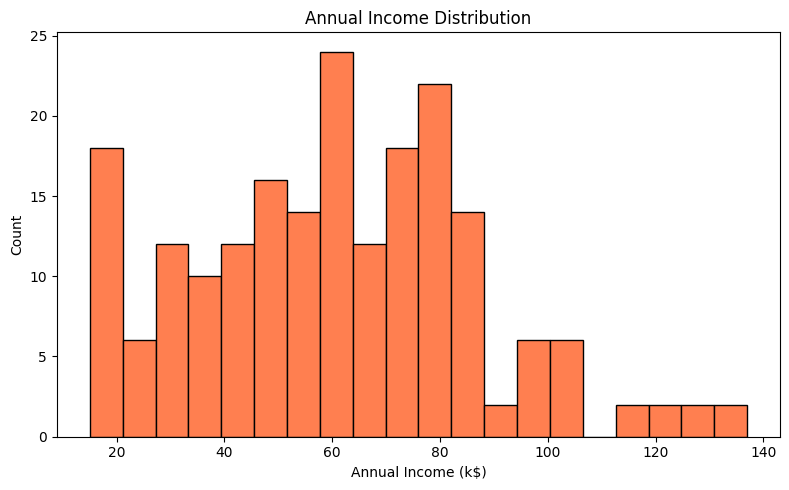

In [24]:
# Cell 8 - Annual Income Distribution
plt.figure(figsize=(8, 5))
plt.hist(df['annual_income'], bins=20, color='coral', edgecolor='black')
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

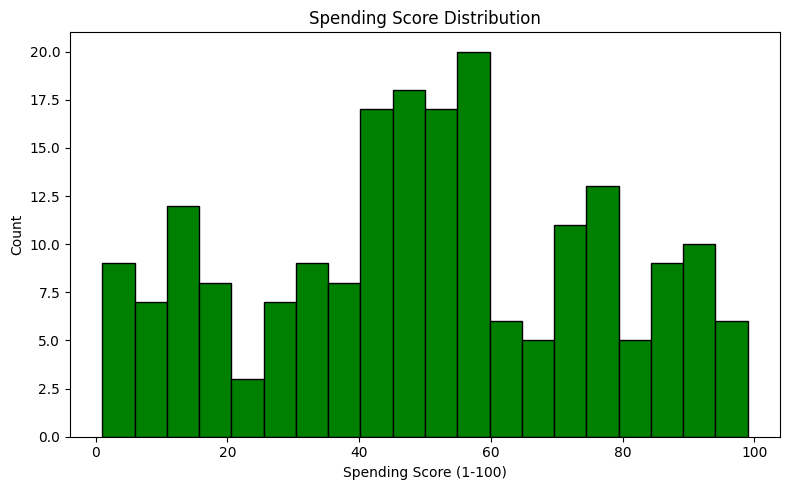

In [25]:
# Cell 9 - Spending Score Distribution
plt.figure(figsize=(8, 5))
plt.hist(df['spending_score'], bins=20, color='green', edgecolor='black')
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

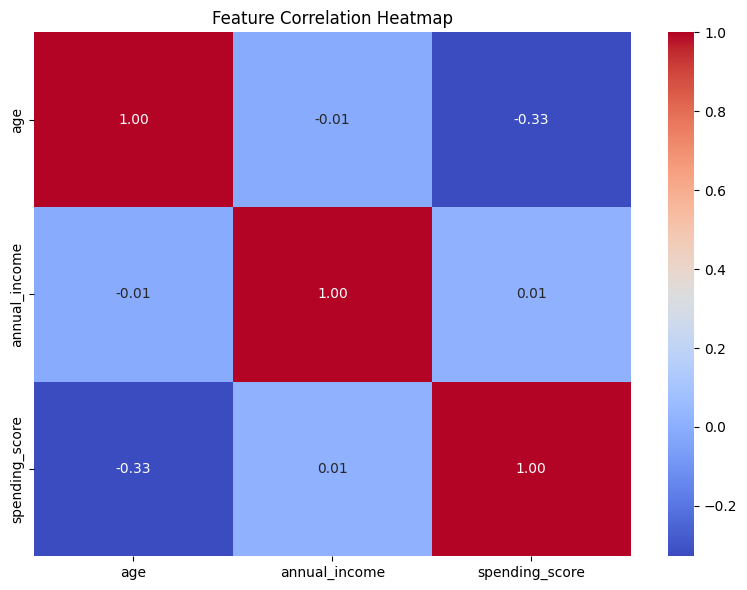

In [27]:
# Cell 10 - Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(columns=['customer_id', 'Gender']).corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 11 - Feature Selection for Clustering
# Using Annual Income and Spending Score for 2D clustering
X = df[['annual_income', 'spending_score']]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Cell 12 - Elbow Method to find Optimal K
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 13 - Silhouette Score to confirm Optimal K
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k} Silhouette Score: {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='coral', linewidth=2)
plt.title('Silhouette Score for Different K Values')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

In [ ]:
# Cell 14 - Apply K-Means with Optimal K=5
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(df['cluster'].value_counts())

In [ ]:
# Cell 15 - Visualize Clusters
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'orange', 'purple']
cluster_labels = {
    0: 'Low Income Low Spending',
    1: 'High Income High Spending',
    2: 'Low Income High Spending',
    3: 'High Income Low Spending',
    4: 'Average Income Average Spending'
}

for cluster in range(5):
    subset = df[df['cluster'] == cluster]
    plt.scatter(subset['annual_income'], subset['spending_score'],
                label=cluster_labels[cluster],
                color=colors[cluster], alpha=0.7, s=80)

# Plot cluster centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1],
            s=200, c='black', marker='*', label='Centroids')

plt.title('Customer Segments — Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 16 - Cluster Analysis
cluster_summary = df.groupby('cluster').agg(
    Total_Customers  = ('customer_id', 'count'),
    Avg_Age          = ('age', 'mean'),
    Avg_Income       = ('annual_income', 'mean'),
    Avg_Spending     = ('spending_score', 'mean')
).round(2)

cluster_summary['Cluster Label'] = cluster_summary.index.map(cluster_labels)
print(cluster_summary)

In [ ]:
# Cell 17 - Gender Distribution per Cluster
gender_cluster = df.groupby(['cluster', 'gender']).size().unstack()
gender_cluster.plot(kind='bar', figsize=(10, 5),
                    color=['coral', 'steelblue'], edgecolor='black')
plt.title('Gender Distribution per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 18 - Age Distribution per Cluster
plt.figure(figsize=(10, 5))
for cluster in range(5):
    subset = df[df['cluster'] == cluster]
    plt.hist(subset['age'], bins=15, alpha=0.5,
             label=cluster_labels[cluster], edgecolor='black')
plt.title('Age Distribution per Cluster')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 19 - 3D Clustering (Age, Income, Spending Score)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for cluster in range(5):
    subset = df[df['cluster'] == cluster]
    ax.scatter(subset['age'], subset['annual_income'], subset['spending_score'],
               label=cluster_labels[cluster], alpha=0.6, s=60)

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score')
ax.set_title('3D Customer Segmentation')
ax.legend(loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 20 - Save Cleaned Dataset
df.to_csv('mall_customers_clustered.csv', index=False)
print('Saved successfully!')
df.head()